# CIFAR-10 Fully Connected Network (FCN)

This notebook implements image classification on the **CIFAR-10** dataset using a **Fully Connected Network (FCN)**

## 1. Environment Setup

We use Keras 3 with the PyTorch backend.
Keras 3 is backend-agnostic, so the same model code runs on PyTorch, TensorFlow, or JAX.
PyTorch is chosen here because it gives easy access to CUDA GPU acceleration.

In [17]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import torch
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"Keras version:   {keras.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("WARNING: GPU not found – training will be slow on CPU!")

PyTorch version: 2.11.0+cu128
Keras version:   3.12.1
CUDA available:  True


## 2. Load and Explore the Data

CIFAR-10 is built into Keras. We load it and immediately normalise pixel values from **[0, 255]** to **[0.0, 1.0]**.
Normalisation is critical for gradient-based optimisers: without it, large raw pixel values cause exploding gradients
and much slower convergence.

Unlike MNIST (grayscale, 28×28), CIFAR-10 images are:
- **3 channels** (R, G, B)
- **32×32 pixels**
- Giving a raw input dimensionality of **32 × 32 × 3 = 3 072** per image.

In [18]:
from keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255.0
x_test  = x_test  / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

### 2.1 Sample images from each class

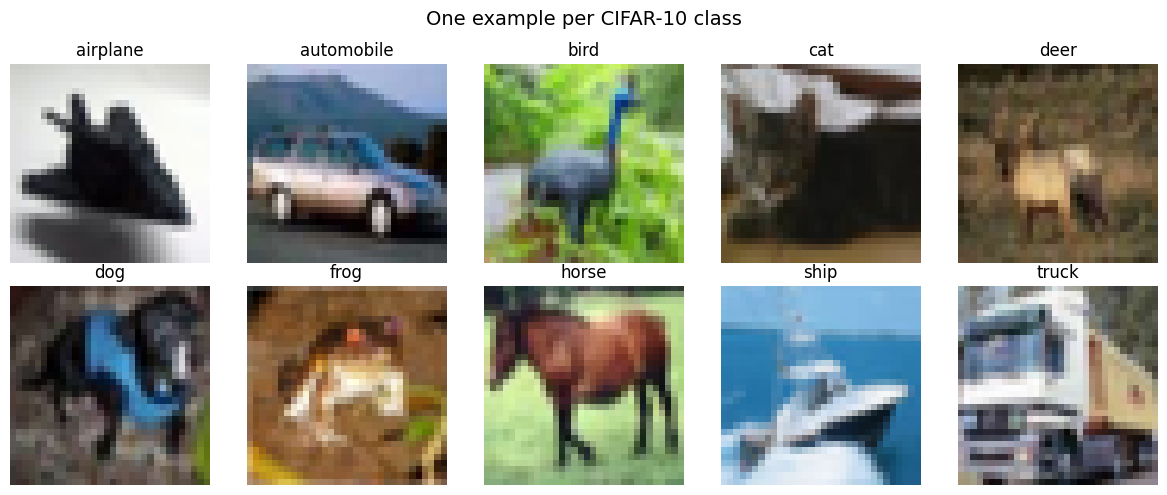

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('One example per CIFAR-10 class', fontsize=14)

for cls_idx, ax in enumerate(axes.flat):
    sample_idx = np.where(y_train.flatten() == cls_idx)[0][0]
    ax.imshow(x_train[sample_idx])
    ax.set_title(class_names[cls_idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Build the FCN Model

In [20]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),    
    layers.Flatten(),

    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adamw',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,746 (14.67 MB)

 Trainable params: 3,840,906 (14.65 MB)

 Non-trainable params: 3,840 (15.00 KB)

## 4. Train the FCN

We train for **10 epochs** with a batch size of **64**.
20 % of the training data is held out as a **validation set** (not used for gradient updates)
so we can monitor overfitting during training.

In [21]:
import time

t0 = time.time()
history_fcn = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    verbose=1
)
fcn_train_time = time.time() - t0
print(f"\nTraining time: {fcn_train_time:.1f} s")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.2762 - loss: 2.0940 - val_accuracy: 0.3050 - val_loss: 1.9247
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3586 - loss: 1.7877 - val_accuracy: 0.3732 - val_loss: 1.7513
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3801 - loss: 1.7232 - val_accuracy: 0.3753 - val_loss: 1.7235
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3850 - loss: 1.7132 - val_accuracy: 0.3806 - val_loss: 1.7150
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3926 - loss: 1.6917 - val_accuracy: 0.3823 - val_loss: 1.7179
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3974 - loss: 1.6853 - val_accuracy: 0.4207 - val_loss: 1.6182
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4041 - loss: 1.6684 - val_accuracy: 0.4013 - val_loss: 1.6586
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4003 - loss: 1.6714 - val_accu

### 4.1 Learning Curves


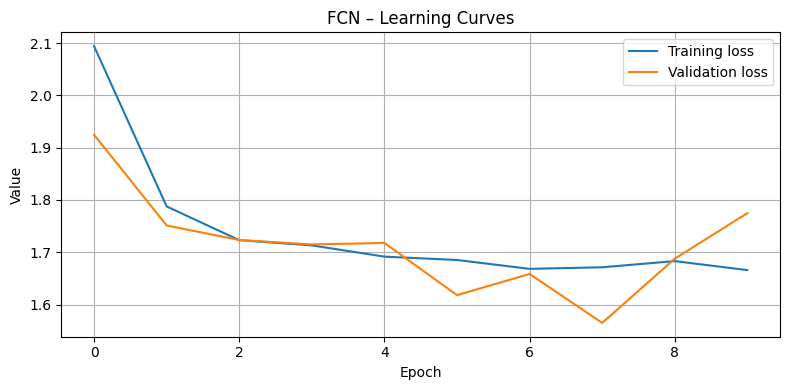

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(history_fcn.history['loss'],     label='Training loss')
plt.plot(history_fcn.history['val_loss'],  label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('FCN – Learning Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.2 Test Accuracy

We evaluate the trained model on the **held-out test set** (10 000 images the model has never seen).
This is the definitive measure of generalisation performance.

In [23]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nFCN  –  Test loss: {test_loss:.4f}   |   Test accuracy: {test_acc*100:.2f} %")
print(f"Training time: {fcn_train_time:.1f} s")
print(f"Total parameters: {model.count_params():,}")

313/313 - 3s - 8ms/step - accuracy: 0.3638 - loss: 1.7605

FCN  –  Test loss: 1.7605   |   Test accuracy: 36.38 %
Training time: 79.0 s
Total parameters: 3,844,746


## 5. Visualise Predictions

For each test image we display:
- **Left:** the actual image with the true label
- **Right:** the model's predicted probability for each class

A confident correct prediction produces a bar chart dominated by one tall bar on the right class.
A confused prediction spreads probability mass across multiple classes.

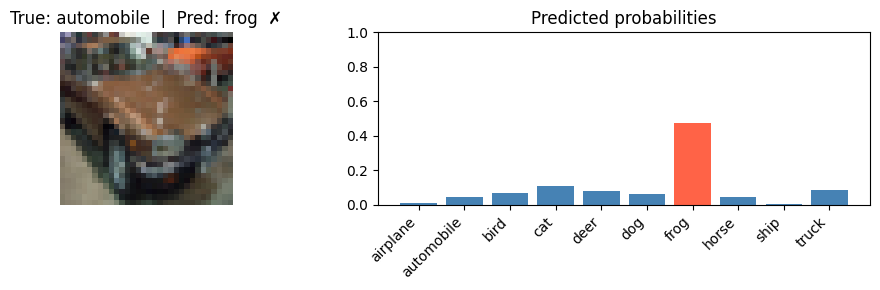

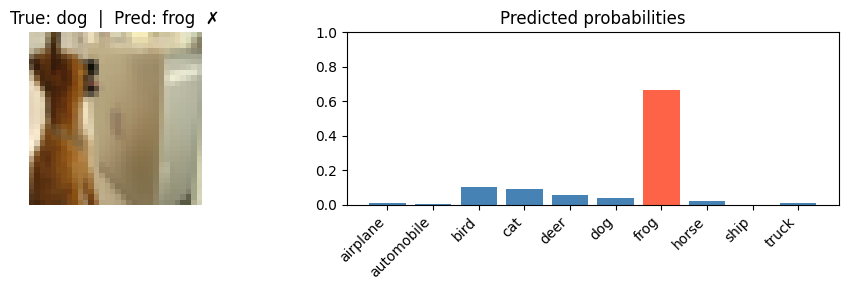

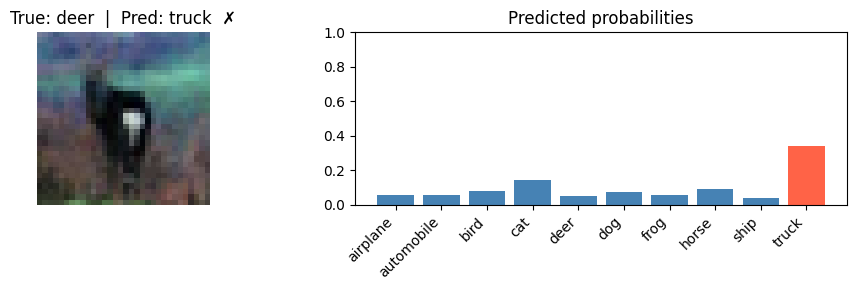

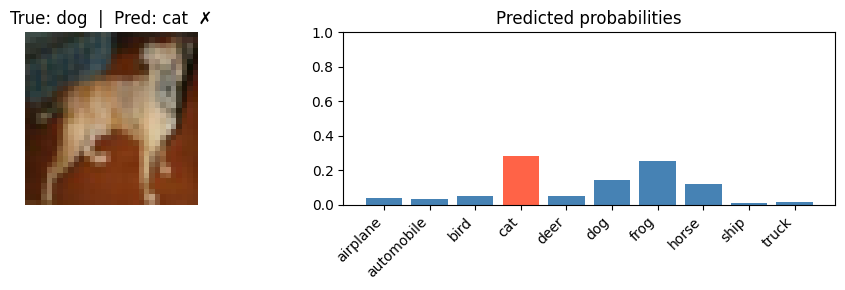

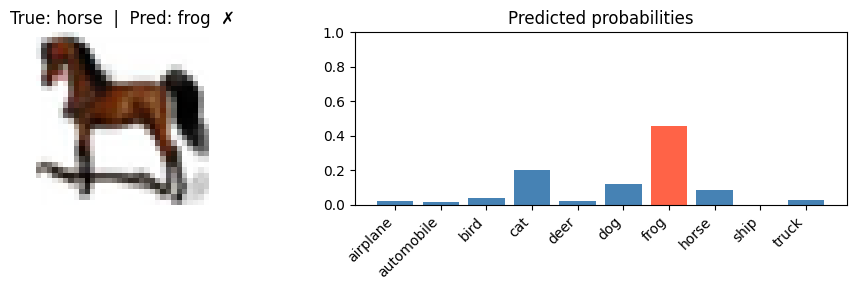

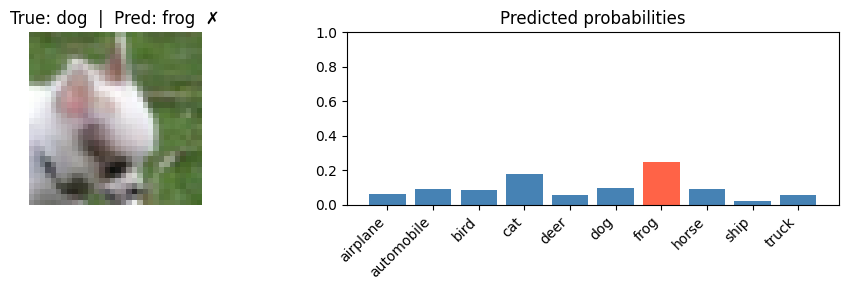

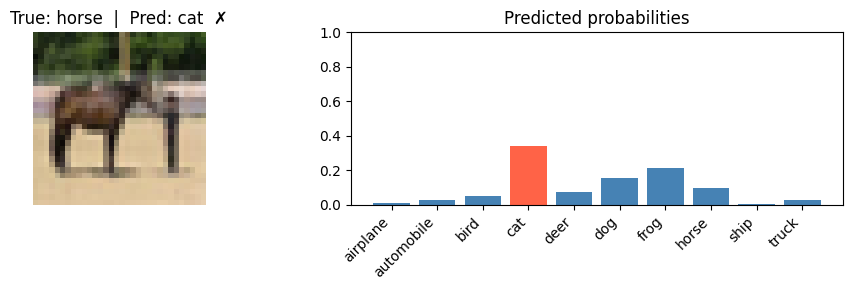

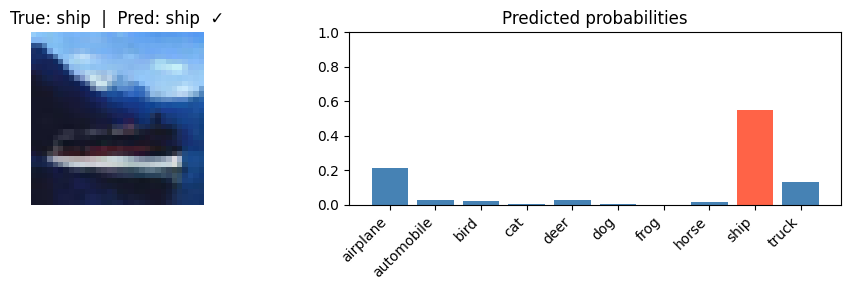

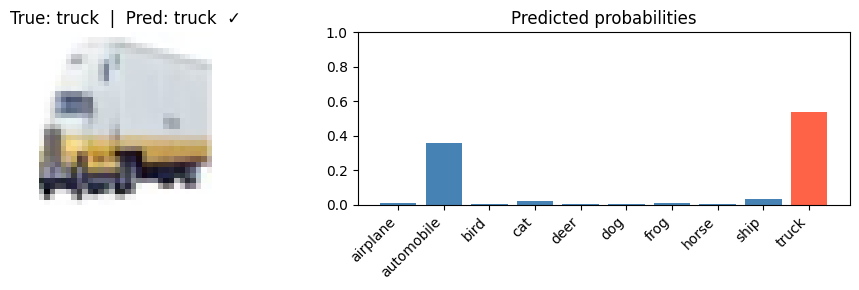

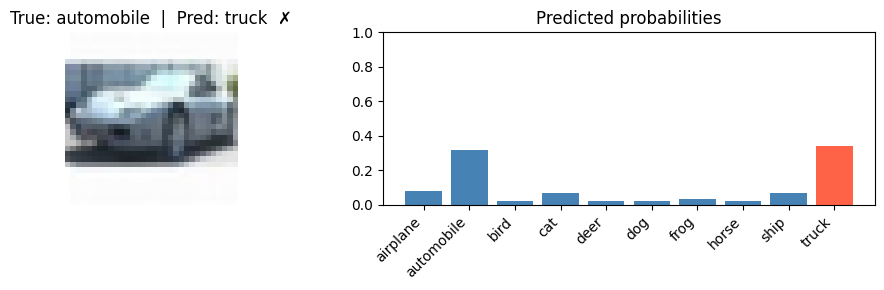

In [24]:
y_pred_fcn = model.predict(x_test, verbose=0)

start = 2000
for k in range(10):
    idx = start + k
    true_label = class_names[y_test[idx][0]]
    pred_label = class_names[np.argmax(y_pred_fcn[idx])]
    correct = '✓' if true_label == pred_label else '✗'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

    ax1.imshow(x_test[idx])
    ax1.set_title(f"True: {true_label}  |  Pred: {pred_label}  {correct}")
    ax1.axis('off')

    colors = ['steelblue'] * 10
    colors[np.argmax(y_pred_fcn[idx])] = 'tomato'
    ax2.bar(range(10), y_pred_fcn[idx], color=colors)
    ax2.set_xticks(range(10))
    ax2.set_xticklabels(class_names, rotation=45, ha='right')
    ax2.set_ylim([0, 1])
    ax2.set_title('Predicted probabilities')

    plt.tight_layout()
    plt.show()

## 6. Analyse Misclassified Images

We display the 10 most *confidently wrong* predictions — cases where the model was very sure
but predicted the wrong class. These are the most interesting failures.

Total misclassified: 6362 / 10000

10 most confidently wrong predictions:


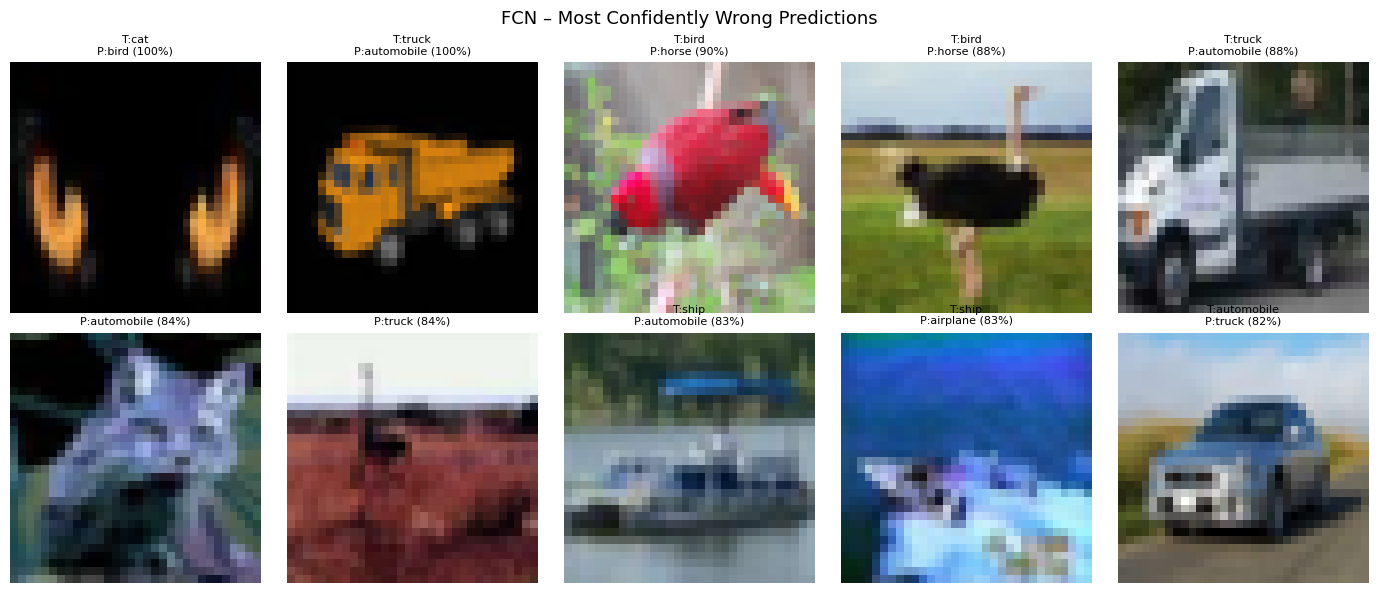

In [25]:
y_true_flat = y_test.flatten()
y_pred_labels = np.argmax(y_pred_fcn, axis=1)

wrong_mask = y_pred_labels != y_true_flat
wrong_indices = np.where(wrong_mask)[0]

# Sort by confidence in the (wrong) prediction
confidence_wrong = y_pred_fcn[wrong_indices, y_pred_labels[wrong_indices]]
sorted_order = np.argsort(confidence_wrong)[::-1][:10]
top_wrong = wrong_indices[sorted_order]

print(f"Total misclassified: {wrong_mask.sum()} / {len(y_true_flat)}")
print("\n10 most confidently wrong predictions:")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('FCN – Most Confidently Wrong Predictions', fontsize=13)
for ax, idx in zip(axes.flat, top_wrong):
    ax.imshow(x_test[idx])
    true_cls = class_names[y_true_flat[idx]]
    pred_cls = class_names[y_pred_labels[idx]]
    conf     = confidence_wrong[sorted_order[list(top_wrong).index(idx)]]
    ax.set_title(f"T:{true_cls}\nP:{pred_cls} ({conf:.0%})", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Summary

### Why does FCN struggle with image data?

1. **No spatial awareness:** Flattening destroys all 2-D spatial relationships.
   A cat in the top-left corner looks completely different to the network than the same cat in the bottom-right.
2. **No weight sharing:** Each pixel position has its own set of weights.
   This leads to a huge number of parameters (~1.7 M here) that must all be learned from data.
3. **No translation invariance:** The model must independently learn that a 'dog' can appear anywhere in the image.
4. **High parameter count → overfitting:** Without architectural priors, the model tends to memorise training patterns
   rather than learning generalisable features.

Despite these limitations, FCN can still learn some useful statistics from colour histograms and global
texture patterns, which is why it beats random chance (10 %) and reaches ~50 %.